# API structure


<pre>
quantkit/
├── config.py
└── pricing/
    └── core/
        ├── instruments.py
        ├── market.py
        ├── pricer.py
        ├── engines/
        │   ├── binomial_tree.py
        │   ├── bsm.py
        │   └── lsmc.py
        └── utils/
            ├── boundary.py
            ├── graphs.py
            └── visualization.py

tests/
├── conftest.py
├── test_binomial_tree.py
├── test_bsm.py
├── test_lsmc.py
└── test_pricing_invariants.py
</pre>

- `quantkit/`: Main package for the pricing engine.
- `quantkit/config.py`: Configuration values used across the package.
- `quantkit/pricing/`: Pricing-related modules and subpackages.
- `quantkit/pricing/core/`: Core domain logic for instruments, market data, and pricing.
- `quantkit/pricing/core/instruments.py`: Defines financial instruments such as options.
- `quantkit/pricing/core/market.py`: Holds market data and related parameters.
- `quantkit/pricing/core/pricer.py`: Base pricing logic and common pricing interface.
- `quantkit/pricing/engines/`: Different pricing engine implementations.
- `quantkit/pricing/engines/binomial_tree.py`: Binomial tree pricing model.
- `quantkit/pricing/engines/bsm.py`: Black-Scholes-Merton pricing model.
- `quantkit/pricing/engines/lsmc.py`: Least-squares Monte Carlo pricing model.
- `quantkit/pricing/utils/`: Utility functions used by the pricing modules.
- `quantkit/pricing/utils/boundary.py`: Helper methods for exercise boundary logic.
- `quantkit/pricing/utils/graphs.py`: Plotting and graphing utilities.
- `quantkit/pricing/utils/visualization.py`: Visualization helpers for pricing results.
- `tests/`: Automated test suite for the package.
- `tests/conftest.py`: Shared pytest fixtures and test setup.
- `tests/test_binomial_tree.py`: Tests for the binomial tree engine.
- `tests/test_bsm.py`: Tests for the Black-Scholes-Merton engine.
- `tests/test_lsmc.py`: Tests for the LSMC engine.
- `tests/test_pricing_invariants.py`: Tests for general pricing invariants and consistency.

# Pricing using the Binomial Tree and BSM Engine


In [15]:
import sys
import os

sys.path.append(os.path.abspath('..'))


import numpy as np
from datetime import datetime
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData, DividendEvent
from quantkit.pricing.core.pricer import Pricer
from quantkit.pricing.utils.visualization import *
from quantkit.pricing.utils.graphs import *

# Base No-Dividend Market
market_no_div = MarketData(spot=100.0, rate=0.05, volatility=0.2)

# Base Dividend Market
divs = [DividendEvent(time=0.5, amount=2.0), DividendEvent(time=0.8, amount=2.0)]
market_div = MarketData(spot=100.0, rate=0.05, volatility=0.2, discrete_dividends=divs)

eur_call = Option(100.0, 1.0, OptionType.CALL, OptionStyle.EUROPEAN)
eur_put = Option(100.0, 1.0, OptionType.PUT, OptionStyle.EUROPEAN)
am_call = Option(100.0, 1.0, OptionType.CALL, OptionStyle.AMERICAN)
am_put = Option(100.0, 1.0, OptionType.PUT, OptionStyle.AMERICAN)

## 1. Example - to show output + show plots for the same

One example each for European call, put and American call, put - print out the price, and add a graph for exercise boundaries (graphs should also show the param values)

Boundary times for American Call should be empty or NaN since it's never optimal to exercise early:
[]


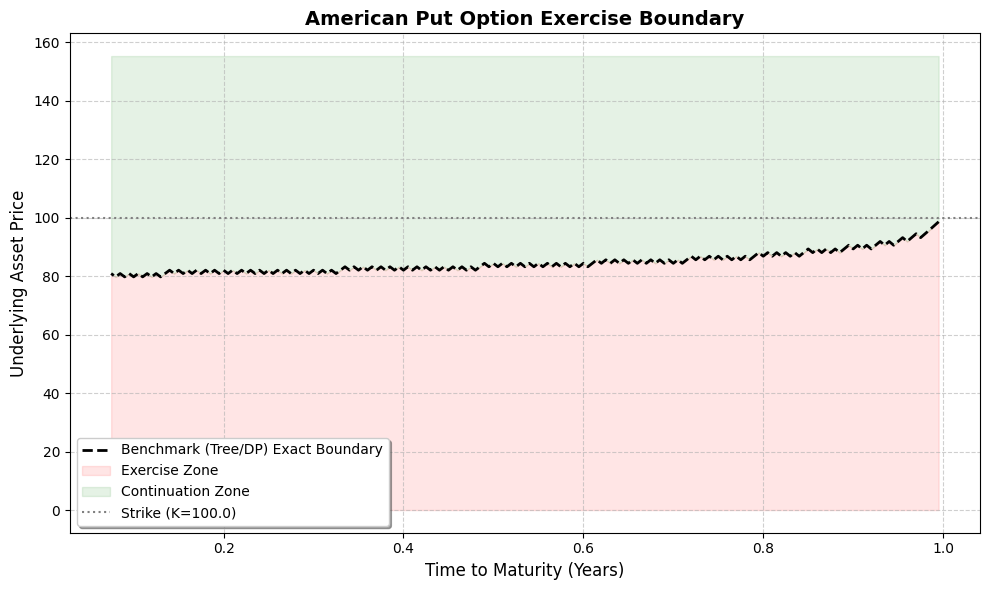

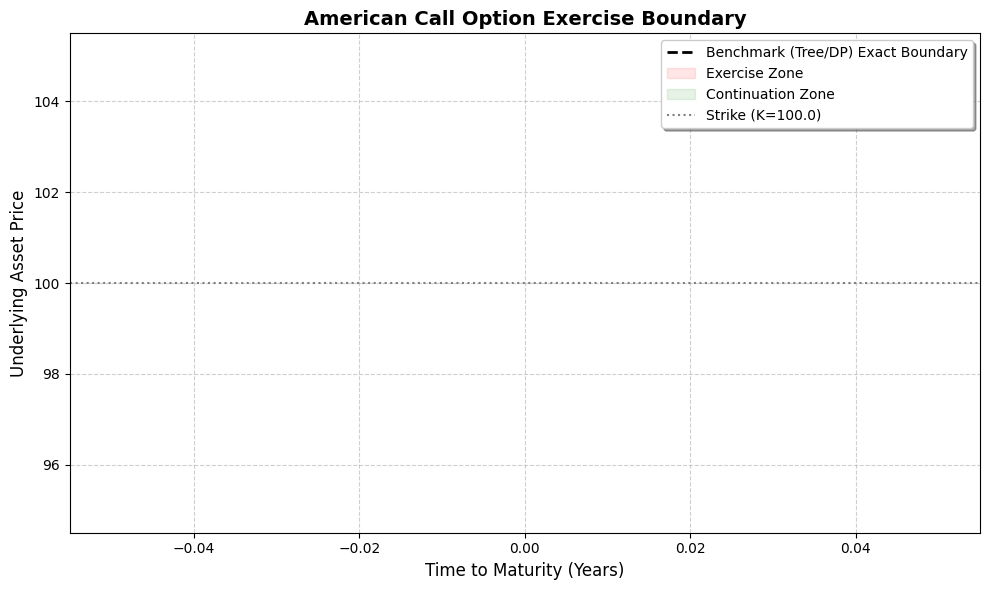

In [2]:
eur_call_example = Pricer.price(eur_call, market_no_div, engine='bsm')
am_put_example = Pricer.price(am_put, market_no_div, engine='binomial', steps=200)
am_call_example = Pricer.price(am_call, market_no_div, engine='binomial', steps=200)


print("Boundary times for American Call should be empty or NaN since it's never optimal to exercise early:")
print(am_call_example.boundary_times)

plot_exercise_boundary_binomial_bsm(am_put, am_put_example, title="American Put Option Exercise Boundary")
plot_exercise_boundary_binomial_bsm(am_call, am_call_example, title="American Call Option Exercise Boundary")

## 2. Convergence Analysis

### 2.1 Binomial Tree - Steps versus Price (error) 

1. Error plots are for European and American calls, and European Puts with no dividends - directly comparable with BSM price.

2. For American puts - we just plot price vs steps


### 2.2 Runtime vs Price error


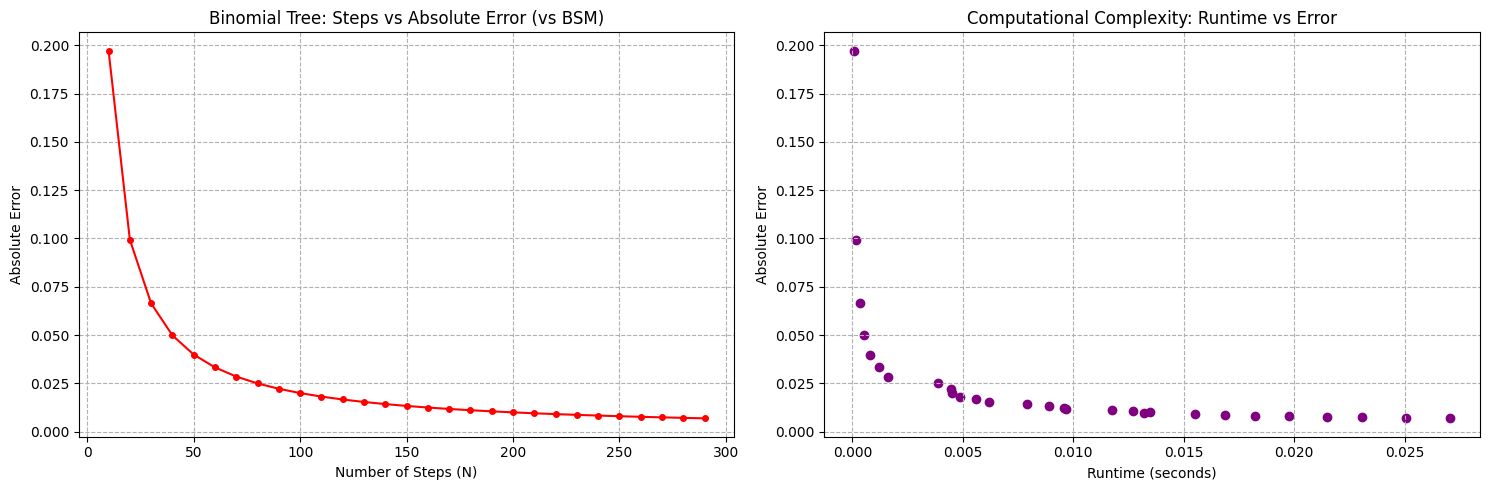

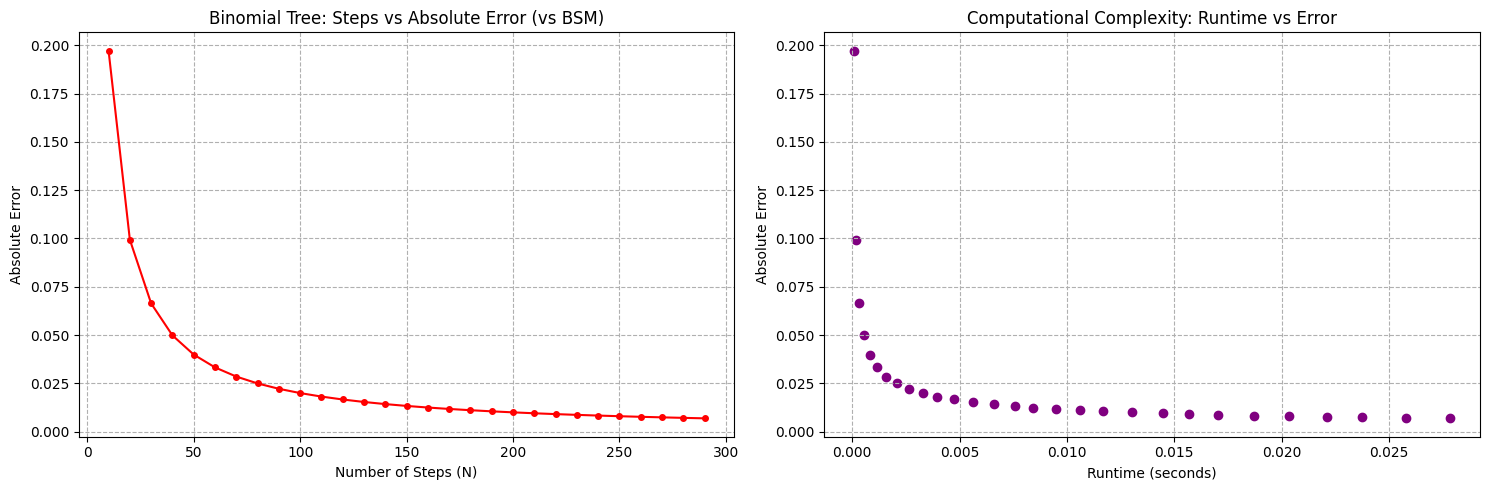

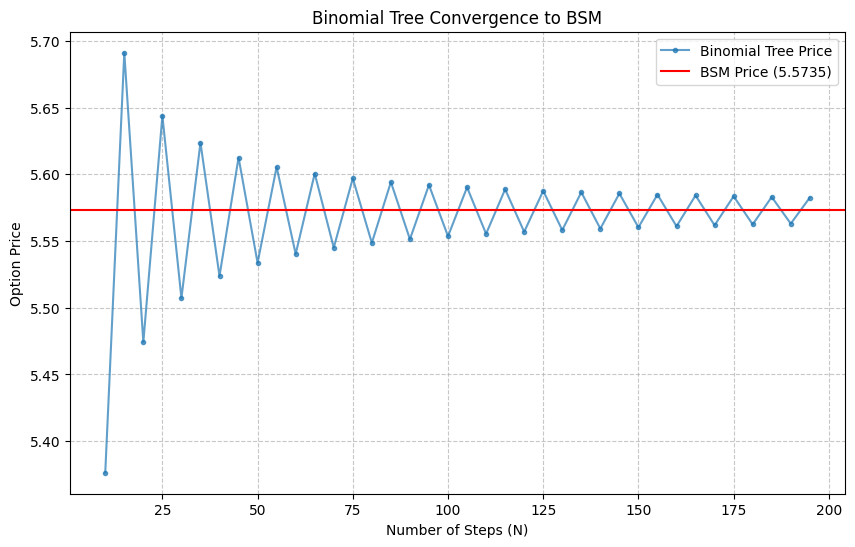

In [3]:
# 2.1 & 2.2: Binomial Tree Steps vs Price Error AND Runtime vs Error
plot_convergence_error_and_time(eur_put, market_no_div, step_range=range(10, 300, 10))

plot_convergence_error_and_time(eur_call, market_no_div, step_range=range(10, 300, 10))

# For American Puts, BSM isn't accurate, so we just plot price vs steps
plot_binomial_convergence(eur_put, market_no_div, step_range=range(10, 200, 5)) # Proxy test

## 3. Graphs for both Put and call - assuming no dividends, for everything

1. Delta (prices wrt spot)
2. Theta (prices wrt time)
3. Vega (prices wrt sigma)
4. Rho (prices wrt riskfree rate)

We have also included the Deep ITM European Put case 

Delta Proxy:


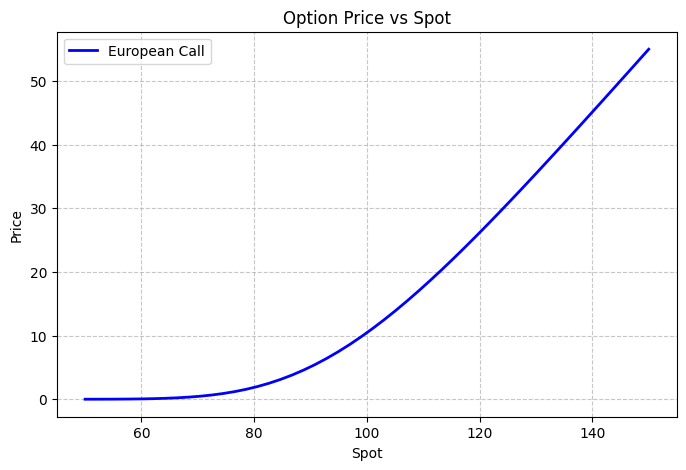

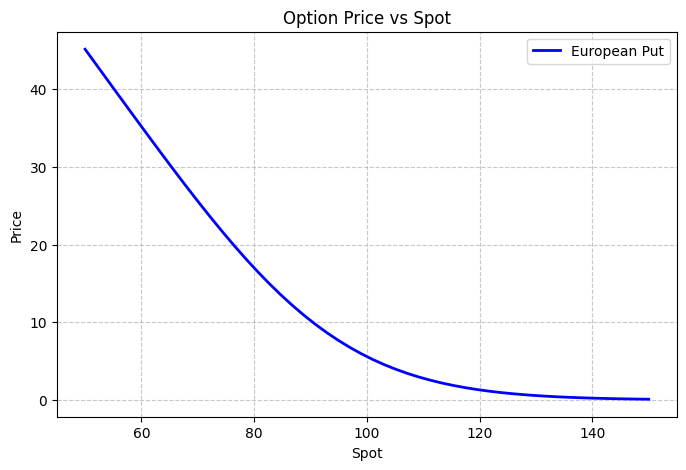

Vega Proxy:


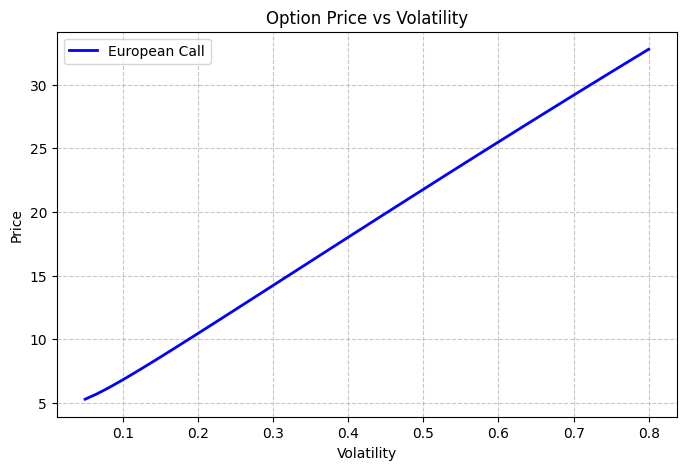

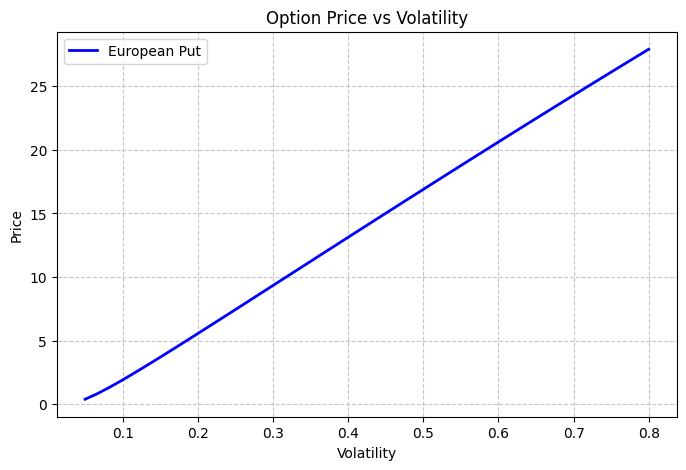

Theta Proxy:


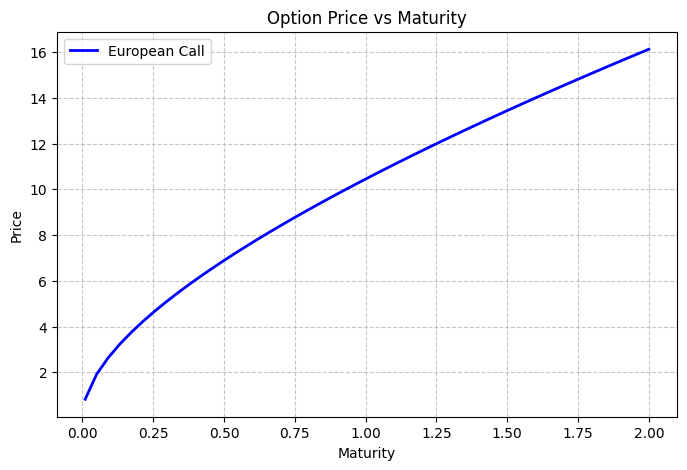

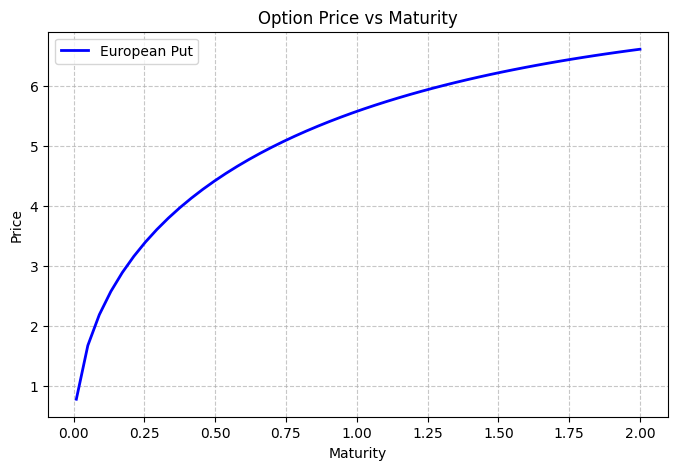

Rho Proxy:


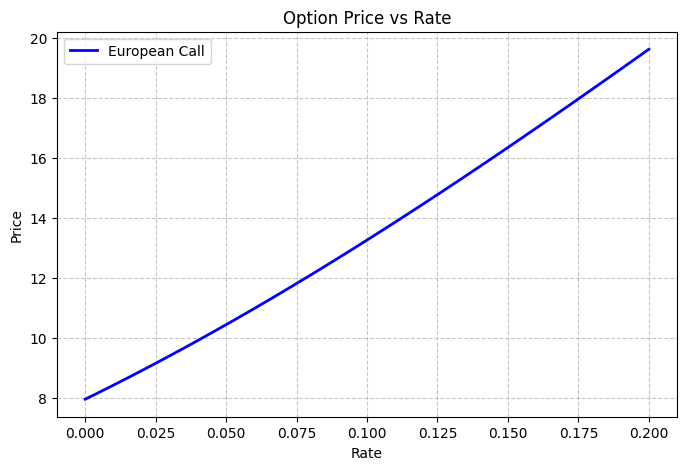

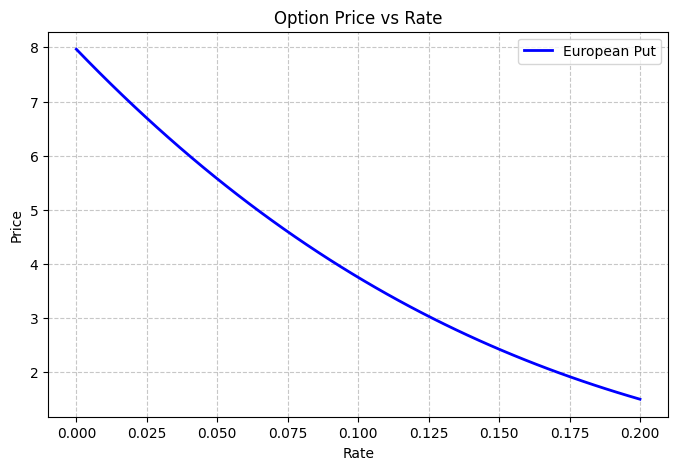

Deep ITM European Put for Theta:


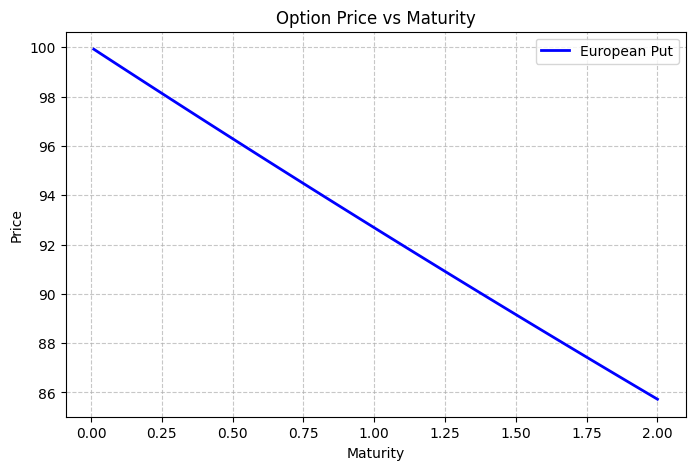

In [4]:
spot_range = np.linspace(50, 150, 50)
vol_range = np.linspace(0.05, 0.8, 50)
time_range = np.linspace(0.01, 2.0, 50)
rate_range = np.linspace(0.0, 0.2, 50)

# Delta Proxy
print("Delta Proxy:")
plot_sensitivities(eur_call, market_no_div, 'spot', spot_range, engine="bsm")
plot_sensitivities(eur_put, market_no_div, 'spot', spot_range, engine="bsm")

# Vega Proxy
print("Vega Proxy:")
plot_sensitivities(eur_call, market_no_div, 'volatility', vol_range, engine="binomial", steps=200)
plot_sensitivities(eur_put, market_no_div, 'volatility', vol_range, engine="binomial", steps=200)

# Theta Proxy
print("Theta Proxy:")
plot_sensitivities(eur_call, market_no_div, 'maturity', time_range, engine="bsm")
plot_sensitivities(eur_put, market_no_div, 'maturity', time_range, engine="bsm")

# Rho Proxy
print("Rho Proxy:")
plot_sensitivities(eur_call, market_no_div, 'rate', rate_range, engine="bsm")
plot_sensitivities(eur_put, market_no_div, 'rate', rate_range, engine="bsm")



print("Deep ITM European Put for Theta:")
# IMPORTANT CASE: Deep ITM European Put for Theta
# Notice how the curve bends upward as time approaches 0 (meaning positive theta!)
deep_itm_put = Option(strike=150.0, maturity=2.0, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN)
market_low_spot = MarketData(spot=50.0, rate=0.05, volatility=0.2)
plot_sensitivities(deep_itm_put, market_low_spot, 'maturity', time_range, engine="bsm")

## 4. Put call parity for European - with and without dividends with 5 examples

In [5]:
examples = [
    {'strike': 90.0, 'maturity': 0.5},
    {'strike': 100.0, 'maturity': 1.0},
    {'strike': 110.0, 'maturity': 1.0},
    {'strike': 100.0, 'maturity': 2.0},
    {'strike': 120.0, 'maturity': 0.25}
]

print("--- WITHOUT Dividends ---")
display(generate_put_call_parity_table(market_no_div, examples))

print("\n--- WITH Discrete Dividends ---")
display(generate_put_call_parity_table(market_div, examples))

--- WITHOUT Dividends ---


,Strike,Maturity,Call Price,Put Price,C - P (LHS),S - PV(K) - PV(Div) (RHS),Diff (Error)
0,90.0,0.50,13.4985,1.2764,12.2221,12.2221,0.0
1,100.0,1.00,10.4506,5.5735,4.8771,4.8771,0.0
2,110.0,1.00,6.0401,10.6753,-4.6352,-4.6352,0.0
3,100.0,2.00,16.1268,6.6105,9.5163,9.5163,0.0
4,120.0,0.25,0.1998,18.7091,-18.5093,-18.5093,0.0



--- WITH Discrete Dividends ---


,Strike,Maturity,Call Price,Put Price,C - P (LHS),S - PV(K) - PV(Div) (RHS),Diff (Error)
0,90.0,0.50,13.4985,1.2764,12.2221,12.2221,0.0
1,100.0,1.00,8.1300,7.1252,1.0049,1.0049,0.0
2,110.0,1.00,4.4475,12.9550,-8.5074,-8.5074,0.0
3,100.0,2.00,13.5530,7.9089,5.6441,5.6441,0.0
4,120.0,0.25,0.1998,18.7091,-18.5093,-18.5093,0.0


## 5. Plots for bounds 

The graph is the spot price vs price for a fixed K, r and volatility, plotting the price, upper and lower bounds
for both BSM and binomial (relatively high Number of steps)

Plots are for 
1. Binomial - European call, put with and without discrete dividends + American call, put with discrete dividends,
2. BSM - Europen call put - with and without continuous yield

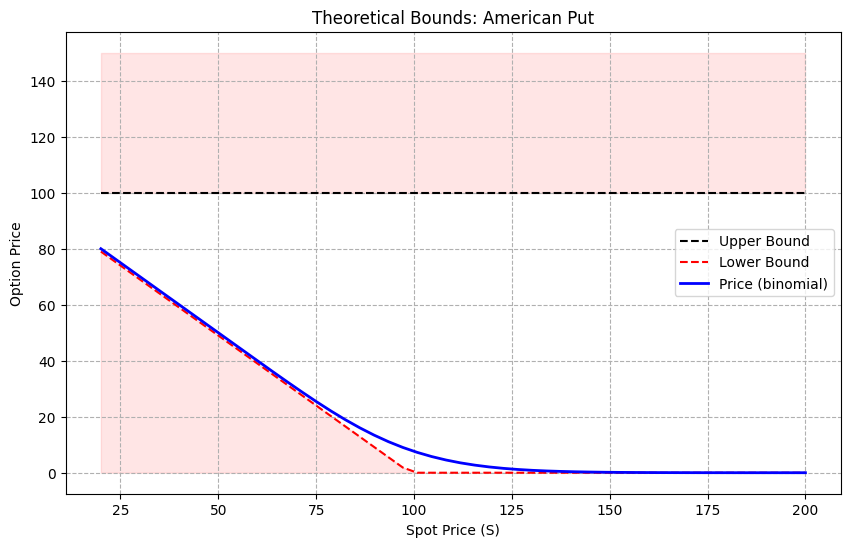

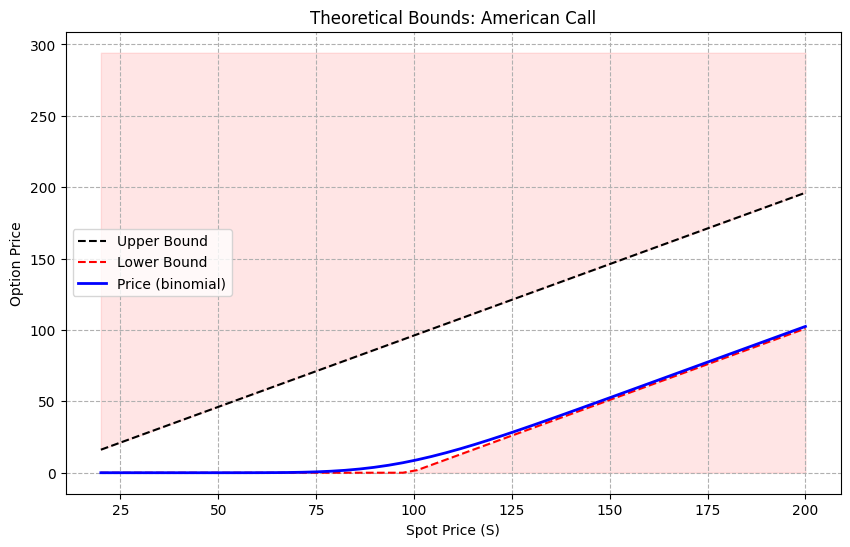

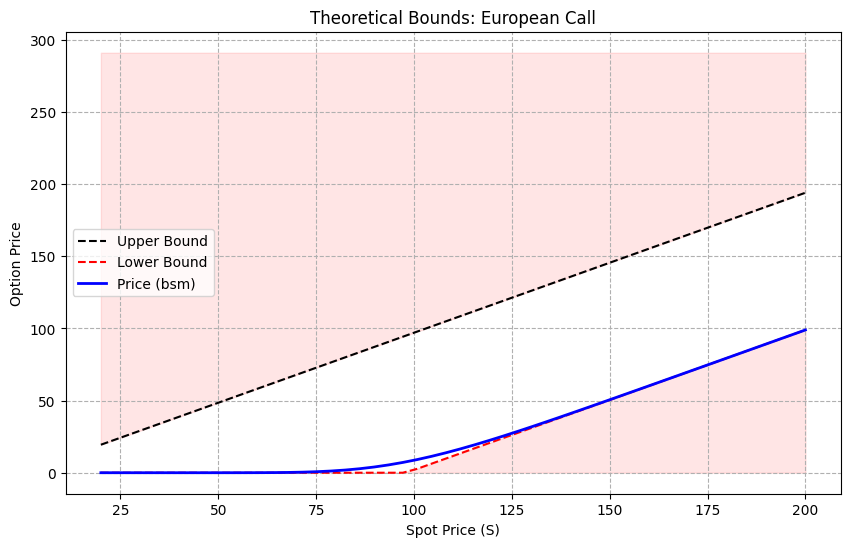

In [6]:
spot_range = np.linspace(20, 200, 50)

# 1. Binomial - American Put with discrete dividends
plot_price_bounds(am_put, market_div, spot_range, engine="binomial", steps=150)

plot_price_bounds(am_call, market_div, spot_range, engine="binomial", steps=150)

# 2. BSM - European Call with continuous yield
market_yield = MarketData(spot=100.0, rate=0.05, volatility=0.2, dividend_yield=0.03)
plot_price_bounds(eur_call, market_yield, spot_range, engine="bsm")

## 6.  P >= p - no dividends

1. Show as a table for different params

In [7]:
# Show as a table for different params[cite: 18]
strikes = [90, 100, 110]
maturities = [0.5, 1.0, 2.0]

df_premium = generate_american_vs_european_table(market_no_div, strikes, maturities, OptionType.PUT)
display(df_premium) #[cite: 19]

,Type,Strike,Maturity,European Price,American Price,Early Exercise Premium,Invariant Holds?
0,Put,90,0.5,1.2813,1.3288,0.0475,True
1,Put,90,1.0,2.3128,2.4745,0.1617,True
2,Put,90,2.0,3.4752,3.9427,0.4675,True
3,Put,100,0.5,4.4103,4.6514,0.2411,True
4,Put,100,1.0,5.5602,6.0850,0.5248,True
5,Put,100,2.0,6.5917,7.7158,1.1241,True
6,Put,110,0.5,10.1872,10.9700,0.7828,True
7,Put,110,1.0,10.6672,11.9696,1.3024,True
8,Put,110,2.0,10.9732,13.2593,2.2861,True


## 7. Option prices + stock prices across 20 days - compare with BSM given the spot price, experiment over different values of sigma

In [8]:
import yfinance as yf

# 1. Initialize the ticker
ticker = yf.Ticker("AAPL")

# 2. Get available expiration dates
expirations = ticker.options
print(f"Available Expirations: {expirations}")

# 3. Get the option chain for a specific date (e.g., the first one)
opt_chain = ticker.option_chain(expirations[0])

# 4. Access the 'puts' DataFrame
puts_df = opt_chain.puts

# 5. Display the first few rows of put data
print(puts_df[['contractSymbol', 'strike', 'lastPrice', 'bid', 'ask', 'volume']])


Available Expirations: ('2026-05-06', '2026-05-08', '2026-05-11', '2026-05-13', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
         contractSymbol  strike  lastPrice    bid    ask  volume
0   AAPL260506P00200000   200.0       0.01   0.00   0.01       4
1   AAPL260506P00205000   205.0       0.06   0.00   0.06       2
2   AAPL260506P00210000   210.0       0.05   0.00   0.10       2
3   AAPL260506P00215000   215.0       0.07   0.00   0.30       2
4   AAPL260506P00220000   220.0       0.06   0.00   0.08       2
5   AAPL260506P00225000   225.0       0.01   0.00   0.01       1
6   AAPL260506P00230000   230.0       0.06   0.00   0.30       1
7   AAPL260506P00235000   235.0       0.08   0.00   0.30      82
8   AAPL260506P00237500   237.5       0.01   0.00   0.01      40
9   

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData
from quantkit.pricing.core.pricer import Pricer

TICKERS  = ["GOOGL", "MSFT", "AAPL"]
T        = 30 / 365   # 30-day option, fixed throughout
r        = 0.05
N_STEPS  = 150        # binomial steps

raw = yf.download(TICKERS, period="40d", auto_adjust=True)["Close"].dropna().tail(20)
print(raw)

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL       GOOGL        MSFT
Date                                          
2026-04-08  258.899994  317.320007  374.329987
2026-04-09  260.489990  318.489990  373.070007
2026-04-10  260.480011  317.239990  370.869995
2026-04-13  259.200012  321.309998  384.369995
2026-04-14  258.829987  332.910004  393.109985
2026-04-15  266.429993  337.119995  411.220001
2026-04-16  263.399994  336.019989  420.260010
2026-04-17  270.230011  341.679993  422.790009
2026-04-20  273.049988  337.420013  418.070007
2026-04-21  266.170013  332.290009  424.160004
2026-04-22  273.170013  339.320007  432.920013
2026-04-23  273.429993  338.890015  415.750000
2026-04-24  271.059998  344.399994  424.619995
2026-04-27  267.609985  350.339996  424.820007
2026-04-28  270.709991  349.779999  429.250000
2026-04-29  270.170013  349.940002  424.459991
2026-04-30  271.350006  384.799988  407.779999
2026-05-01  280.140015  385.690002  414.440002
2026-05-04  276.829987  383.250000  413.619995
2026-05-05  2

In [10]:
def hist_vol(prices: pd.Series) -> float:
    """Annualised vol from daily log-returns (full window)."""
    log_rets = np.log(prices / prices.shift(1)).dropna()
    return float(log_rets.std() * np.sqrt(252))

results = {}   # ticker -> DataFrame

for ticker in TICKERS:
    spots  = raw[ticker]
    sigma  = hist_vol(spots)           # single vol for the whole window
    rows   = []

    for date, S in spots.items():
        K = round(S)                   # ATM strike
        mkt = MarketData(spot=S, rate=r, volatility=sigma)

        eu_put = Pricer.price(
            Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN),
            mkt, engine="bsm"
        ).price

        am_put = Pricer.price(
            Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.AMERICAN),
            mkt, engine="binomial", steps=N_STEPS
        ).price

        rows.append({"date": date, "spot": S, "eu_put_bsm": eu_put,
                     "am_put_binomial": am_put, "sigma": sigma})

    results[ticker] = pd.DataFrame(rows).set_index("date")

results["GOOGL"].head()

,spot,eu_put_bsm,am_put_binomial,sigma
date,,,,
2026-04-08,317.320007,12.991087,13.065499,0.381016
2026-04-09,318.489990,12.954573,13.032732,0.381016
2026-04-10,317.239990,13.027898,13.100578,0.381016
2026-04-13,321.309998,13.161469,13.236515,0.381016
2026-04-14,332.910004,13.843634,13.918690,0.381016


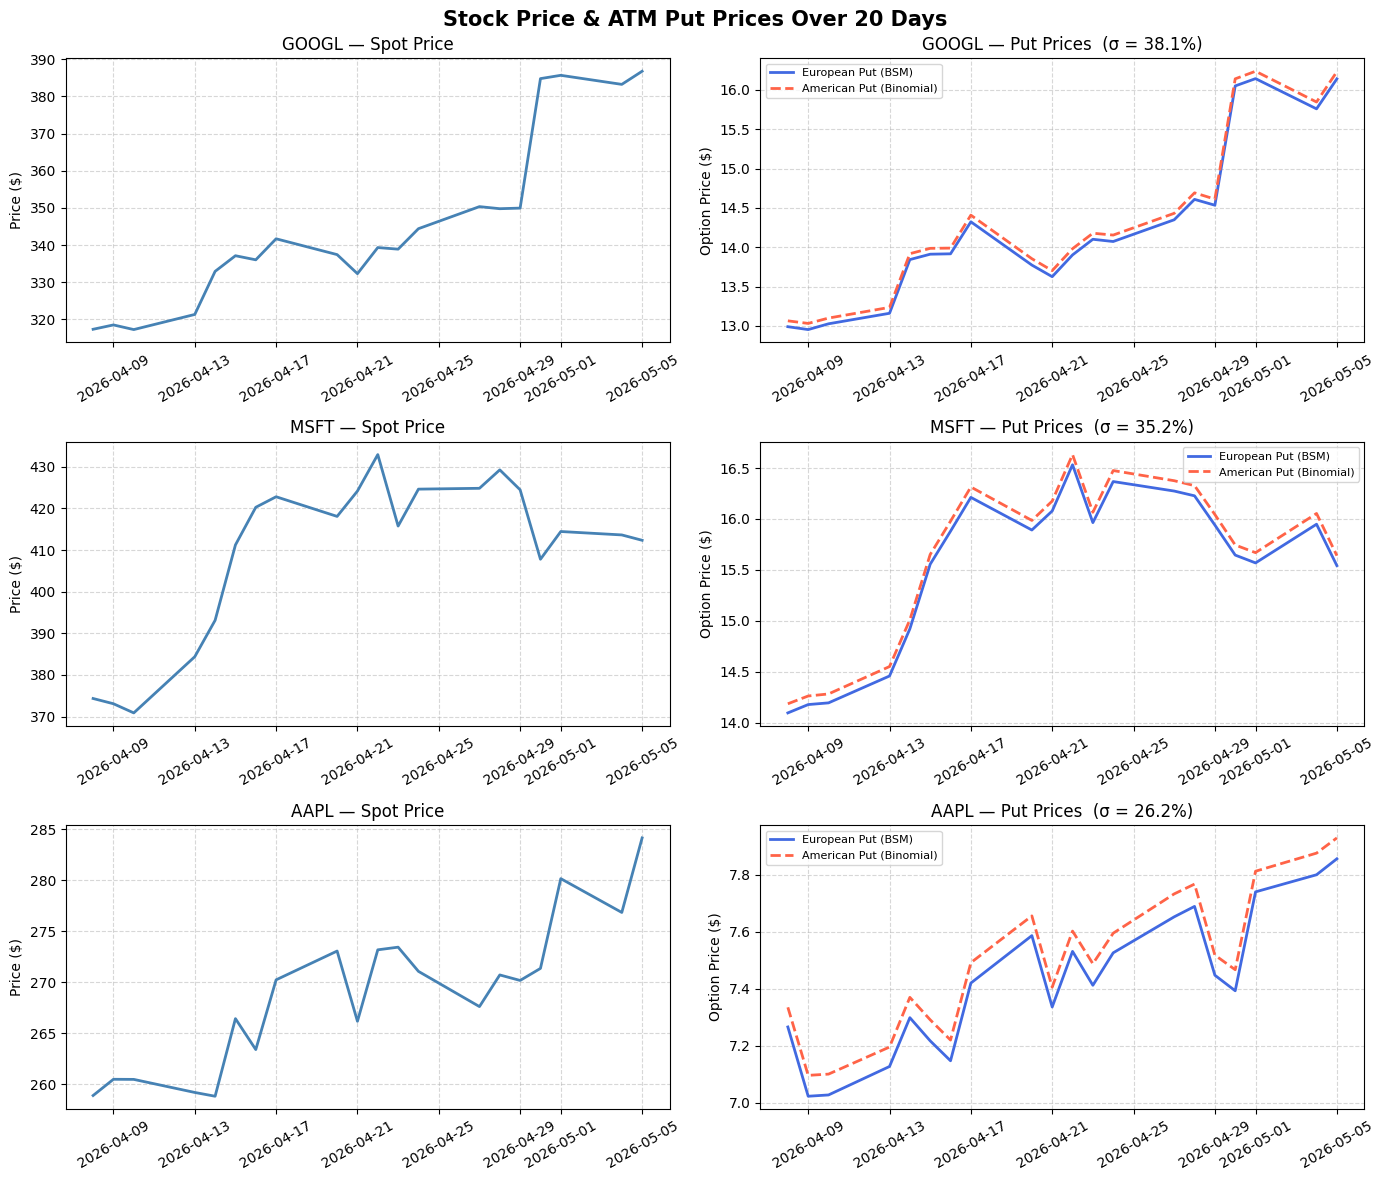

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Stock Price & ATM Put Prices Over 20 Days", fontsize=15, fontweight="bold")

for i, ticker in enumerate(TICKERS):
    df = results[ticker]

    # Left: spot price
    ax_s = axes[i, 0]
    ax_s.plot(df.index, df["spot"], color="steelblue", linewidth=2)
    ax_s.set_title(f"{ticker} — Spot Price")
    ax_s.set_ylabel("Price ($)")
    ax_s.tick_params(axis="x", rotation=30)
    ax_s.grid(True, linestyle="--", alpha=0.5)

    # Right: option prices
    ax_o = axes[i, 1]
    ax_o.plot(df.index, df["eu_put_bsm"],       label="European Put (BSM)",      color="royalblue",  linewidth=2)
    ax_o.plot(df.index, df["am_put_binomial"],   label="American Put (Binomial)", color="tomato",     linewidth=2, linestyle="--")
    sigma_pct = df["sigma"].iloc[0] * 100
    ax_o.set_title(f"{ticker} — Put Prices  (σ = {sigma_pct:.1f}%)")
    ax_o.set_ylabel("Option Price ($)")
    ax_o.tick_params(axis="x", rotation=30)
    ax_o.legend(fontsize=8)
    ax_o.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

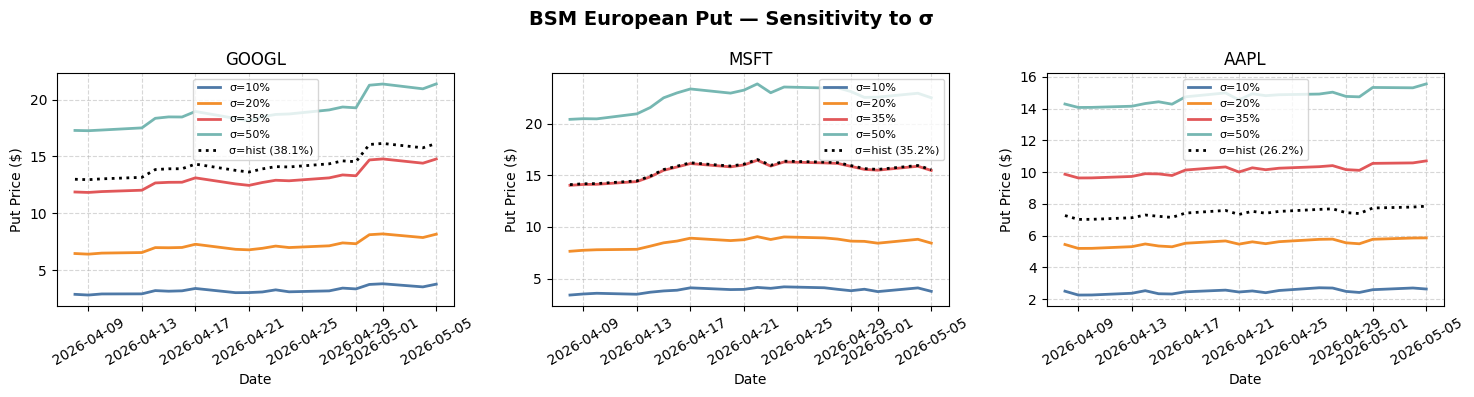

In [12]:
SIGMAS = [0.10, 0.20, 0.35, 0.50]
COLORS = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("BSM European Put — Sensitivity to σ", fontsize=14, fontweight="bold")

for ax, ticker in zip(axes, TICKERS):
    spots = raw[ticker]

    for sigma, color in zip(SIGMAS, COLORS):
        prices = []
        for S in spots:
            K   = round(S)
            mkt = MarketData(spot=S, rate=r, volatility=sigma)
            p   = Pricer.price(
                Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN),
                mkt, engine="bsm"
            ).price
            prices.append(p)
        ax.plot(spots.index, prices, label=f"σ={int(sigma*100)}%", color=color, linewidth=2)

    # Overlay the realised-vol price
    sigma_hist = hist_vol(spots)
    hist_prices = []
    for S in spots:
        K   = round(S)
        mkt = MarketData(spot=S, rate=r, volatility=sigma_hist)
        p   = Pricer.price(
            Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN),
            mkt, engine="bsm"
        ).price
        hist_prices.append(p)
    ax.plot(spots.index, hist_prices, label=f"σ=hist ({sigma_hist*100:.1f}%)",
            color="black", linewidth=2, linestyle=":", zorder=5)

    ax.set_title(ticker)
    ax.set_xlabel("Date")
    ax.set_ylabel("Put Price ($)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Comparing BSM engine with Real Option Prices

### What is an Options Chain?
A stock's **options chain** is the live table of all traded option contracts for that stock — every listed strike and expiry, with real bid/ask prices. We use `(bid + ask) / 2` as the market's best estimate of fair value.

`yfinance` gives us today's full options chain for free.

### What are we doing?
For every strike in the chain, we price the same option through our BSM engine (using today's spot + historically estimated σ), and compare:

> **Market price** (what traders are actually paying) vs **Model price** (what BSM predicts)

We do this across multiple expiry dates (14d, 30d, 60d, 90d out) to see how errors evolve with maturity.

### Why is this interesting?
Our BSM engine uses a **single flat σ across all strikes and maturities**. The market does not.

In a real options chain, implied volatility is higher for deep OTM puts than for ATM puts — a pattern called the **volatility skew**. It exists because the market prices tail risk (sudden crashes) higher than BSM's lognormal assumption allows.

Expected pattern in the error plots:
| Region | Expected BSM Error |
|---|---|
| ATM (K/S ≈ 1.0) | Small — historical σ is roughly calibrated here |
| Deep OTM puts (K/S < 0.9) | BSM **underprices** — market charges a crash premium |
| Longer maturities | Errors grow — flat-vol assumption compounds over time |

This is not a flaw in the implementation — it is BSM's known structural limitation, and the gap between model and market *is* the finding.

In [21]:
TICKER = "AAPL"
r = 0.05

tk  = yf.Ticker(TICKER)
S   = tk.history(period="1d")["Close"].iloc[-1]

print(tk.options[:8])  # Show first 8 expiries for quick reference

# Historical vol from last 60 trading days
hist = tk.history(period="90d")["Close"]
sigma_hist = float(np.log(hist / hist.shift(1)).dropna().std() * np.sqrt(252))

print(f"Spot: ${S:.2f}  |  Historical Vol: {sigma_hist*100:.1f}%")
print(f"Available expiries: {tk.options[:8]} ...")  # yfinance lists all

('2026-05-06', '2026-05-08', '2026-05-11', '2026-05-13', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05')
Spot: $284.43  |  Historical Vol: 24.8%
Available expiries: ('2026-05-06', '2026-05-08', '2026-05-11', '2026-05-13', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05') ...


In [17]:
# Pick a few expiries spread across short / medium / long term
all_expiries = tk.options
today        = datetime.today()

def days_to(exp_str):
    return (datetime.strptime(exp_str, "%Y-%m-%d") - today).days

# Keep expiries between 7 and 180 days out, pick ~5 evenly spaced
candidates = [(e, days_to(e)) for e in all_expiries if 7 < days_to(e) < 180]
step  = max(1, len(candidates) // 5)
chosen_expiries = candidates[::step][:5]

print("Chosen expiries:")
for exp, d in chosen_expiries:
    print(f"  {exp}  ({d} days)")

Chosen expiries:
  2026-05-15  (8 days)
  2026-05-29  (22 days)
  2026-06-12  (36 days)
  2026-07-17  (71 days)
  2026-09-18  (134 days)


In [28]:
S_FIXED = tk.history(period="1d")["Close"].iloc[-1]
rows = []

for exp, d in chosen_expiries:
    puts = tk.option_chain(exp).puts.copy()
    puts = puts[(puts["bid"] > 0) & (puts["ask"] > 0)].copy()

    # Pick the strike closest to S=284 (ATM for this fixed spot)
    puts["dist_to_S"] = (puts["strike"] - S_FIXED).abs()
    atm_row = puts.loc[puts["dist_to_S"].idxmin()].copy()

    rows.append({
        "expiry": exp,
        "days_to_expiry": d,
        "S_used": S_FIXED,
        "strike": float(atm_row["strike"]),
        "moneyness": float(atm_row["strike"] / S_FIXED),
        "bid": float(atm_row["bid"]),
        "ask": float(atm_row["ask"]),
        "mid": float((atm_row["bid"] + atm_row["ask"]) / 2),
        "iv": float(atm_row["impliedVolatility"]) if pd.notna(atm_row["impliedVolatility"]) else np.nan
    })

chain_table = pd.DataFrame(rows).sort_values("expiry")

chain_table_display = chain_table.copy()
chain_table_display["bid"] = chain_table_display["bid"].map(lambda x: f"{x:.2f}")
chain_table_display["ask"] = chain_table_display["ask"].map(lambda x: f"{x:.2f}")
chain_table_display["mid"] = chain_table_display["mid"].map(lambda x: f"{x:.2f}")
chain_table_display["moneyness"] = chain_table_display["moneyness"].map(lambda x: f"{x:.3f}")
chain_table_display["iv"] = chain_table_display["iv"].map(
    lambda x: f"{100*x:.2f}%" if pd.notna(x) else "N/A"
)

display(chain_table_display[["expiry", "days_to_expiry", "S_used", "strike", "moneyness", "bid", "ask", "mid", "iv"]])

,expiry,days_to_expiry,S_used,strike,moneyness,bid,ask,mid,iv
0,2026-05-15,8,284.204987,285.0,1.003,5.05,5.15,5.10,24.02%
1,2026-05-29,22,284.204987,285.0,1.003,6.95,7.20,7.08,22.85%
2,2026-06-12,36,284.204987,285.0,1.003,8.80,9.20,9.00,23.70%
3,2026-07-17,71,284.204987,285.0,1.003,11.60,11.75,11.68,22.20%
4,2026-09-18,134,284.204987,285.0,1.003,16.40,16.55,16.48,23.22%


In [25]:
def price_chain(ticker_obj, expiry: str, S: float, sigma: float, r: float):
    """Fetch real put chain + compute model prices for each strike."""
    T     = days_to(expiry) / 365
    chain = ticker_obj.option_chain(expiry).puts
    chain = chain[(chain["bid"] > 0) & (chain["ask"] > 0)].copy()
    chain["mid"] = (chain["bid"] + chain["ask"]) / 2

    # Reasonable strikes: 75% – 125% of spot
    chain = chain[(chain["strike"] >= 0.75*S) & (chain["strike"] <= 1.25*S)]

    rows = []
    for _, row in chain.iterrows():
        K   = row["strike"]
        mkt = MarketData(spot=S, rate=r, volatility=sigma)

        bsm_price = Pricer.price(
            Option(K, T, OptionType.PUT, OptionStyle.EUROPEAN),
            mkt, engine="bsm"
        ).price

        bin_price = Pricer.price(
            Option(K, T, OptionType.PUT, OptionStyle.AMERICAN),
            mkt, engine="binomial", steps=150
        ).price

        rows.append({
            "strike":     K,
            "moneyness":  K / S,
            "market":     row["mid"],
            "bsm":        bsm_price,
            "binomial":   bin_price,
            "error_bsm":  bsm_price - row["mid"],
            "iv":         row.get("impliedVolatility", np.nan),
            "T":          T,
            "expiry":     expiry,
        })

    return pd.DataFrame(rows)


# Build full results
all_dfs = [price_chain(tk, exp, S, sigma_hist, r) for exp, _ in chosen_expiries]

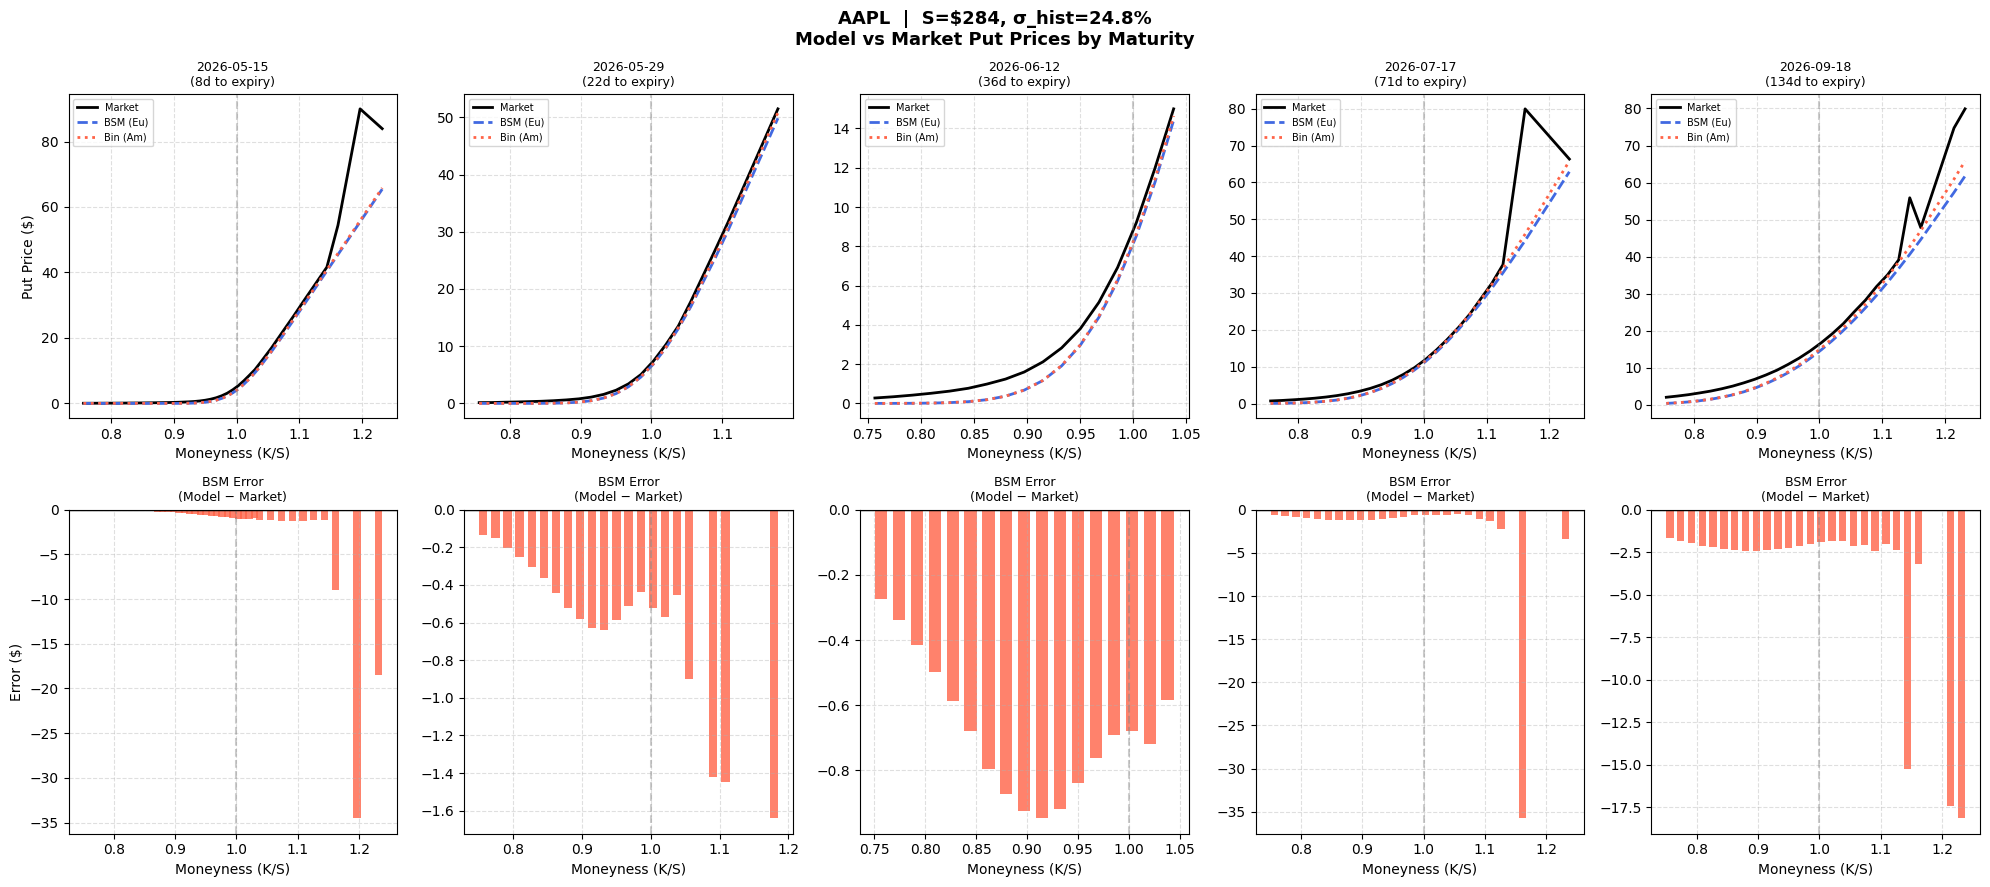

In [19]:
n = len(chosen_expiries)
fig, axes = plt.subplots(2, n, figsize=(4*n, 9))
fig.suptitle(f"{TICKER}  |  S=${S:.0f}, σ_hist={sigma_hist*100:.1f}%\nModel vs Market Put Prices by Maturity",
             fontsize=13, fontweight="bold")

for i, (df, (exp, d)) in enumerate(zip(all_dfs, chosen_expiries)):
    # --- Row 0: price comparison ---
    ax = axes[0, i]
    ax.plot(df["moneyness"], df["market"],   label="Market",    color="black",     lw=2)
    ax.plot(df["moneyness"], df["bsm"],      label="BSM (Eu)",  color="royalblue", lw=2, ls="--")
    ax.plot(df["moneyness"], df["binomial"], label="Bin (Am)",  color="tomato",    lw=2, ls=":")
    ax.axvline(1.0, color="grey", ls="--", alpha=0.4)
    ax.set_title(f"{exp}\n({d}d to expiry)", fontsize=9)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_ylabel("Put Price ($)" if i == 0 else "")
    ax.legend(fontsize=7)
    ax.grid(True, ls="--", alpha=0.4)

    # --- Row 1: BSM error ---
    ax2 = axes[1, i]
    colors = ["royalblue" if e > 0 else "tomato" for e in df["error_bsm"]]
    ax2.bar(df["moneyness"], df["error_bsm"], width=0.012, color=colors, alpha=0.8)
    ax2.axhline(0, color="black", lw=1)
    ax2.axvline(1.0, color="grey", ls="--", alpha=0.4)
    ax2.set_title(f"BSM Error\n(Model − Market)", fontsize=9)
    ax2.set_xlabel("Moneyness (K/S)")
    ax2.set_ylabel("Error ($)" if i == 0 else "")
    ax2.grid(True, ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [20]:
# Clean summary table — ATM row per maturity
print(f"\n{'Expiry':<12} {'Days':>5} {'K(ATM)':>8} {'Market':>8} "
      f"{'BSM':>8} {'Binomial':>10} {'BSM Err':>9} {'Mkt IV':>8}")
print("─" * 75)

for df, (exp, d) in zip(all_dfs, chosen_expiries):
    atm = df.iloc[(df["moneyness"] - 1.0).abs().argsort().iloc[:1]]
    for _, row in atm.iterrows():
        iv_str = f"{row['iv']*100:.1f}%" if not np.isnan(row["iv"]) else "  N/A"
        print(f"{exp:<12} {d:>5} {row['strike']:>8.0f} {row['market']:>8.2f} "
              f"{row['bsm']:>8.2f} {row['binomial']:>10.2f} "
              f"{row['error_bsm']:>+9.2f} {iv_str:>8}")


Expiry        Days   K(ATM)   Market      BSM   Binomial   BSM Err   Mkt IV
───────────────────────────────────────────────────────────────────────────
2026-05-15       8      285     5.42     4.42       4.45     -1.00    25.8%
2026-05-29      22      285     7.40     6.88       6.95     -0.52    24.0%
2026-06-12      36      285     9.20     8.52       8.64     -0.68    24.4%
2026-07-17      71      285    11.95    11.40      11.63     -0.55    22.8%
2026-09-18     134      285    16.70    14.78      15.26     -1.92    23.6%
